# Prac W2 - Supervised Learning (k-NN and Decision Trees)

### Aims:

- To apply k-NN and decision trees as examples of supervised learning models for classification 
and regression problems 
- To get some insight into the trained models, including the infleunce of a hyperparameter in an ML
model
- To produce some assessable work for this project 

### (**Q1**) Make scatter plots of each dataset so you can see what they look like

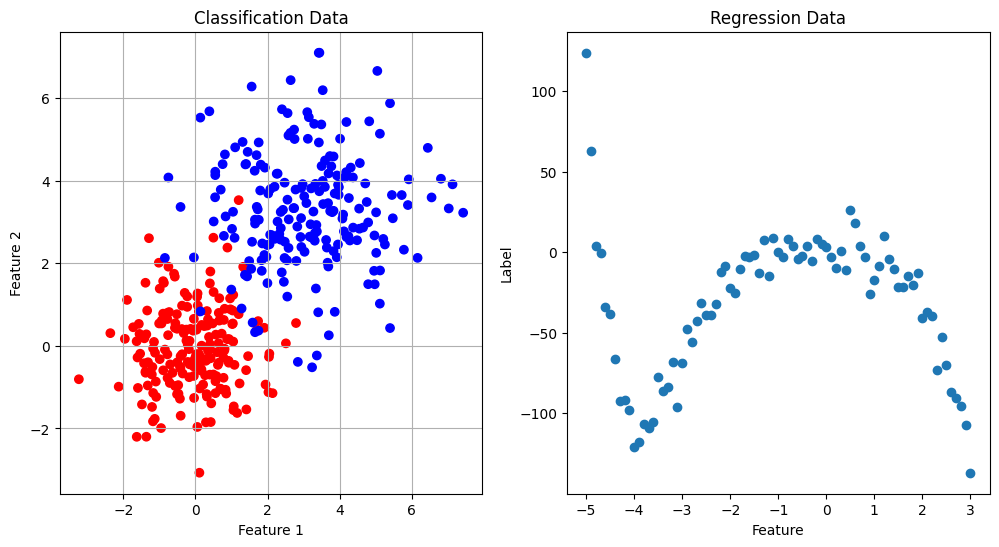

In [68]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from __future__ import annotations

from typing import Tuple

W3CLASSIF_FILEPATH: str = "./datasets/w3classif.csv"
W3REGR_FILEPATH: str = "./datasets/w3regr.csv"

def load_data() -> Tuple[pd.DataFrame, pd.DataFrame]:
    return (
        pd.read_csv(W3CLASSIF_FILEPATH, sep=",", header=None), 
        pd.read_csv(W3REGR_FILEPATH, sep=",", header=None)
    )

def generate_scatterplots(data: Tuple[pd.DataFrame, pd.DataFrame]) -> None:
    fix, axs = plt.subplots(nrows=1, ncols=2, figsize=(12,6))

    # For Classfication data, use first two features for x and y values and label as colour
    classif_data: pd.DataFrame = data[0]
    markers: pd.Series = classif_data.iloc[:, 2].map({ 0: 'red', 1: 'blue' })

    axs[0].set_title("Classification Data")
    axs[0].set_xlabel("Feature 1")
    axs[0].set_ylabel("Feature 2")
    axs[0].scatter(classif_data.iloc[:, 0], classif_data.iloc[:, 1], color=markers)
    axs[0].grid(True)

    # For regression data, use first column for feature, use second column for label
    regr_data: pd.DataFrame = data[1]

    axs[1].set_title("Regression Data")
    axs[1].set_xlabel("Feature")
    axs[1].set_ylabel("Label")
    axs[1].scatter(regr_data.iloc[:, 0], regr_data.iloc[:, 1])

    plt.show()


dfs: Tuple[pd.DataFrame, pd.DataFrame] = load_data()
generate_scatterplots(dfs)


### (**Q2**) Randomly shuffle the datasets (i.e. the order of the rows) and split them each into 
### 70% training and 30% for testing

In [69]:
from sklearn.model_selection import train_test_split

classif_x_train, classif_x_test, classif_y_train, classif_y_test = train_test_split(
    dfs[0].iloc[:, : 2].values, dfs[0].iloc[:, 2].values, test_size=0.3, random_state=67
)

regr_x_train, regr_x_test, regr_y_train, regr_y_test = train_test_split(
    dfs[1].iloc[:, 0].values, dfs[1].iloc[:, 1].values, test_size=0.3, random_state=67
)

regr_x_train = regr_x_train.reshape(-1, 1)
regr_x_test = regr_x_test.reshape(-1, 1)

### (**Q3a**) Build a k-NN classific with k = 3 for dataset w3classif.csv and find the 
### training and test loss (i.e missclassfication rate)

In [70]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

def build_knn_classifier(x_train, y_train, x_test, y_test, k) -> Pipeline:
    # Standardise Values
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=k))
    ])

    model.fit(x_train, y_train)
    y_train_pred = model.predict(x_train)

    train_loss: float = accuracy_score(y_train, y_train_pred) * 100

    print(f"KNN Classifier (k = {k}) Accuracy: {train_loss:.2f}%")

    y_test_pred = model.predict(x_test)

    test_loss: float = accuracy_score(y_test, y_test_pred) * 100

    print(f"KNN Classifier (k = {k}) Accuracy: {test_loss:.2f}%")

    return model

model: Pipeline = build_knn_classifier(
    classif_x_train, 
    classif_y_train, 
    classif_x_test, 
    classif_y_test, 
    3
)


KNN Classifier (k = 3) Accuracy: 95.71%
KNN Classifier (k = 3) Accuracy: 99.17%


### (**Q3B**) Plot the decision regreions for your classifer together with the training and/or test data points

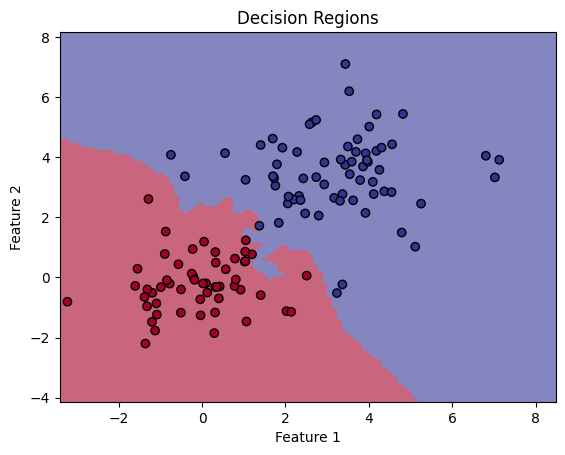

In [71]:
from sklearn.inspection import DecisionBoundaryDisplay

def plot_decision_regions(model: Pipeline, x_train, x, y) -> None:
    fig, ax = plt.subplots()
    DecisionBoundaryDisplay.from_estimator(
        model, 
        x_train, 
        cmap="RdYlBu", 
        ax=ax,
        response_method="predict",
        plot_method="pcolormesh",
        shading="auto",
        alpha=0.6
    )

    ax.scatter(x[:,0], x[:,1], c=y, cmap="RdYlBu", edgecolors="k")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title("Decision Regions")
    plt.show()

plot_decision_regions(model, classif_x_train, classif_x_test, classif_y_test)

### (**Q3c**) Experiment with different $k$ values and see how it affects the loss values and the decision regions

In [72]:
from typing import List

k_grid: List[int] = [1, 3, 5, 10, 20]

for k in k_grid:
    build_knn_classifier(classif_x_train, classif_y_train, classif_x_test, classif_y_test, k)

KNN Classifier (k = 1) Accuracy: 100.00%
KNN Classifier (k = 1) Accuracy: 96.67%
KNN Classifier (k = 3) Accuracy: 95.71%
KNN Classifier (k = 3) Accuracy: 99.17%
KNN Classifier (k = 5) Accuracy: 95.00%
KNN Classifier (k = 5) Accuracy: 99.17%
KNN Classifier (k = 10) Accuracy: 94.64%
KNN Classifier (k = 10) Accuracy: 98.33%
KNN Classifier (k = 20) Accuracy: 94.64%
KNN Classifier (k = 20) Accuracy: 99.17%


### (**Q4A**) Build a $k$-NN regression model with $k$ = 3 for dataset w3regr.csv and find the training and test loss (i.e. sum of squared error)

In [73]:
from sklearn.neighbors import KNeighborsRegressor

def build_knn_regressor(x_train, y_train, x_test, y_test, k) -> Pipeline:
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsRegressor(n_neighbors=k))
    ])

    model.fit(x_train, y_train)
    y_train_pred = model.predict(x_train)

    train_mse = np.sum(np.square(y_train - y_train_pred))
    print(f"KNN Regressor (k = {k}) Train Mean Squared Error: {train_mse:.2f}")

    y_test_pred = model.predict(x_test)
    test_mse = np.sum(np.square(y_test - y_test_pred))
    print(f"KNN Regressor (k = {k}) Test Mean Squared Error: {test_mse:.2f}")

    return model

print(regr_x_train.shape)
regressor = build_knn_regressor(regr_x_train, regr_y_train, regr_x_test, regr_y_test, 3)

(56, 1)
KNN Regressor (k = 3) Train Mean Squared Error: 6123.38
KNN Regressor (k = 3) Test Mean Squared Error: 45305.16


### (**Q4b**) Plot the training and/or test data together with the predicted "function" of the model

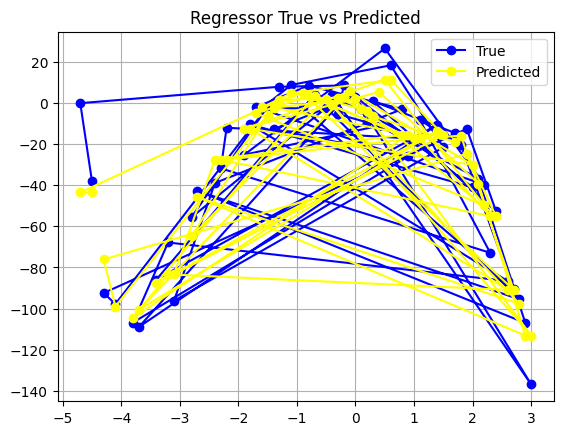

In [74]:
def plot_regressor(model: Pipeline, x, y) -> None:
    y_pred = model.predict(x)

    plt.plot(x, y, label="True", color="blue", marker="o", linestyle="-")
    plt.plot(x, y_pred, label="Predicted", color="yellow", marker="o", linestyle="-")
    plt.title(f"Regressor True vs Predicted")
    plt.grid()
    plt.legend()
    plt.show()

plot_regressor(regressor, regr_x_train, regr_y_train)

### (**Q4C**) Experiment with different $k$ values and see how it affects the loss values and the predicted function

KNN Regressor (k = 1) Train Mean Squared Error: 0.00
KNN Regressor (k = 1) Test Mean Squared Error: 23642.96


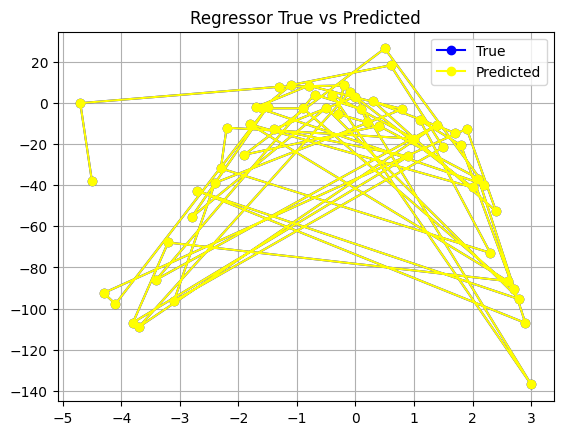

KNN Regressor (k = 3) Train Mean Squared Error: 6123.38
KNN Regressor (k = 3) Test Mean Squared Error: 45305.16


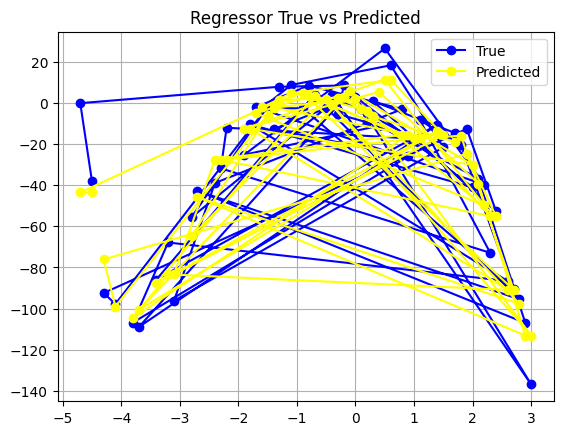

KNN Regressor (k = 5) Train Mean Squared Error: 12124.58
KNN Regressor (k = 5) Test Mean Squared Error: 63686.74


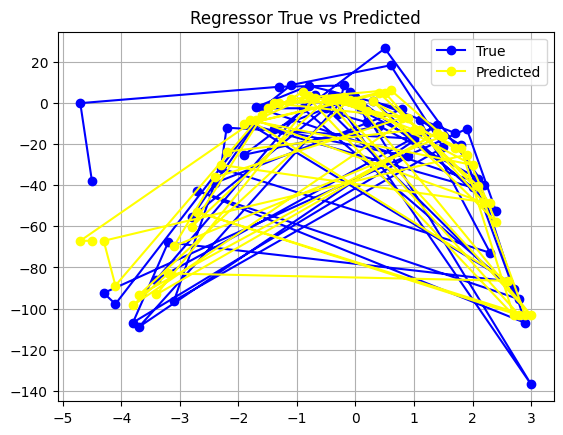

KNN Regressor (k = 10) Train Mean Squared Error: 20654.58
KNN Regressor (k = 10) Test Mean Squared Error: 73379.76


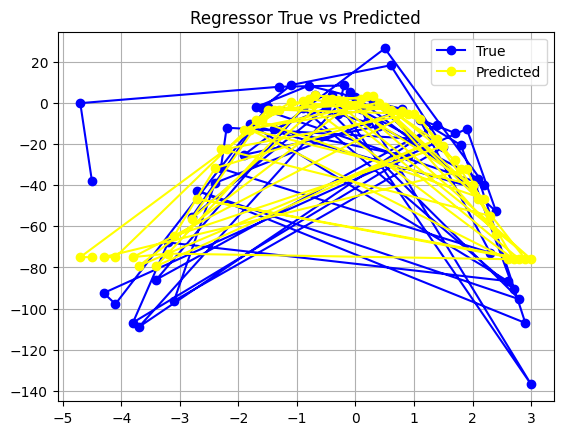

KNN Regressor (k = 20) Train Mean Squared Error: 44792.66
KNN Regressor (k = 20) Test Mean Squared Error: 65394.87


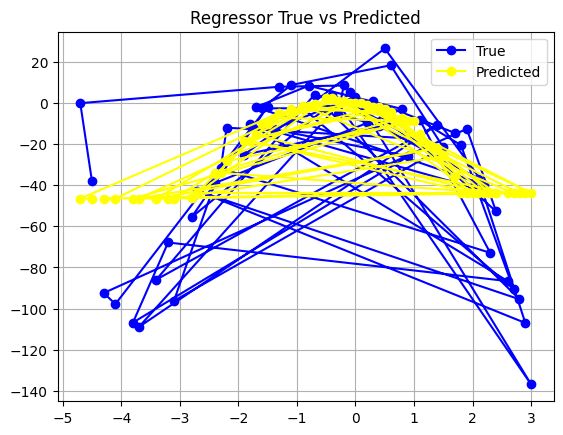

In [75]:
for k in k_grid:
    model = build_knn_regressor(regr_x_train, regr_y_train, regr_x_test, regr_y_test, k)
    plot_regressor(model, regr_x_train, regr_y_train)

### (**Q5A**) Build a decision tree classifier for dataset w3classif.csv and find the training and test loss (i.e. misclassfiication rate)

In [76]:
from sklearn.tree import DecisionTreeClassifier

def build_tree_classifier(x_train, y_train, x_test, y_test, max_depth) -> DecisionTreeClassifier:
    model = DecisionTreeClassifier(max_depth=max_depth).fit(x_train, y_train)

    y_train_pred = model.predict(x_train)
    train_error_rate = 1 - accuracy_score(y_train, y_train_pred) 
    print(f"Tree Classifier (max depth of {max_depth}) Train Error Rate: {train_error_rate}")

    y_test_pred = model.predict(x_test)
    test_error_rate = 1 - accuracy_score(y_test, y_test_pred)
    print(f"Tree Classifier (max_depth of {max_depth}) Test Error Rate: {test_error_rate}")

    return model

tree_clf = build_tree_classifier(
    classif_x_train, 
    classif_y_train, 
    classif_x_test, 
    classif_y_test,
    3
)

Tree Classifier (max depth of 3) Train Error Rate: 0.042857142857142816
Tree Classifier (max_depth of 3) Test Error Rate: 0.025000000000000022


### (**Q5B**) Plot the decision regions for your classifier together with the training and/or test data points 

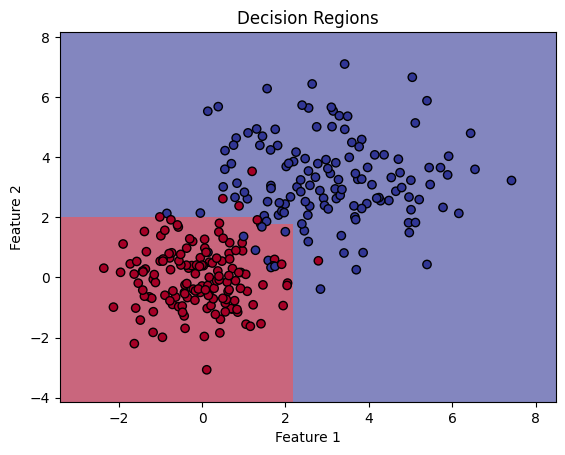

In [77]:
plot_decision_regions(tree_clf, classif_x_train, classif_x_train, classif_y_train)

### (**Q5C**) Experiment with different maximum depth values and see how it affects the loss values and the decision regions

Tree Classifier (max depth of 1) Train Error Rate: 0.08571428571428574
Tree Classifier (max_depth of 1) Test Error Rate: 0.050000000000000044


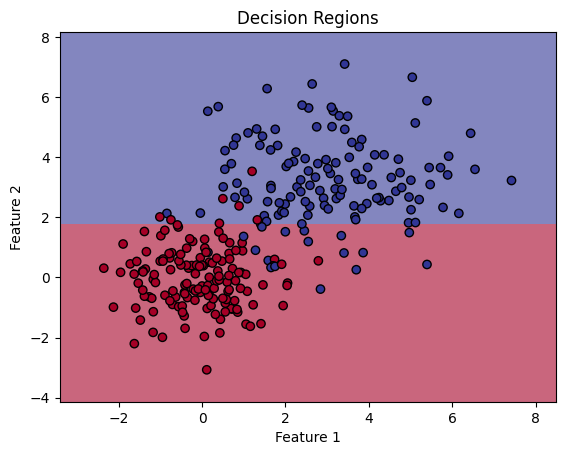

Tree Classifier (max depth of 3) Train Error Rate: 0.042857142857142816
Tree Classifier (max_depth of 3) Test Error Rate: 0.025000000000000022


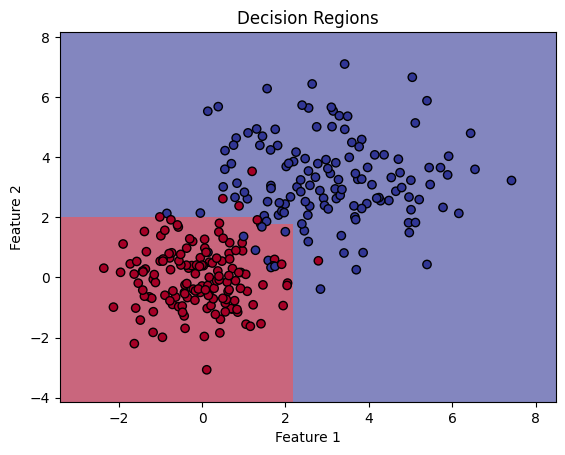

Tree Classifier (max depth of 5) Train Error Rate: 0.017857142857142905
Tree Classifier (max_depth of 5) Test Error Rate: 0.033333333333333326


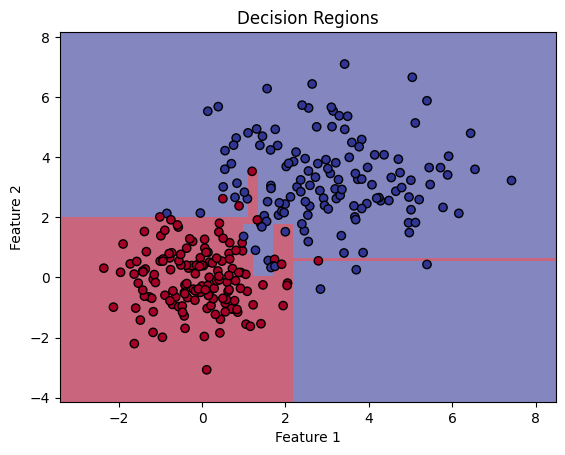

Tree Classifier (max depth of 7) Train Error Rate: 0.0035714285714285587
Tree Classifier (max_depth of 7) Test Error Rate: 0.025000000000000022


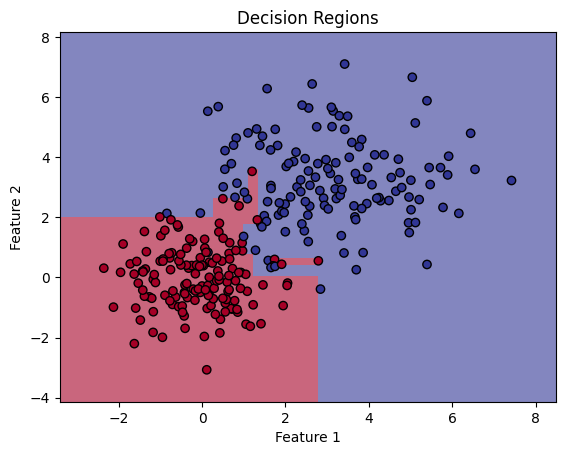

Tree Classifier (max depth of 10) Train Error Rate: 0.0
Tree Classifier (max_depth of 10) Test Error Rate: 0.033333333333333326


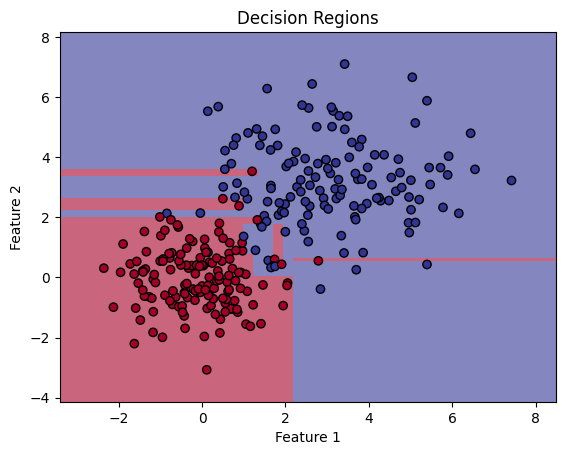

In [78]:
max_depth_grid: List[int] = [1, 3, 5, 7, 10]

for max_depth in max_depth_grid:
    model = build_tree_classifier(
        classif_x_train, 
        classif_y_train, 
        classif_x_test, 
        classif_y_test, 
        max_depth
    )
    plot_decision_regions(model, classif_x_train, classif_x_train, classif_y_train)

### (**Q6A**) Build a decision tree regression model for dataset w3regr.csv and find the training and test loss (i.e. sum of squared error)

In [79]:
from sklearn.tree import DecisionTreeRegressor

def build_tree_regressor(x_train, y_train, x_test, y_test, max_depth) -> DecisionTreeRegressor:
    model = DecisionTreeRegressor(max_depth = max_depth).fit(x_train, y_train)

    y_train_pred = model.predict(x_train)
    train_sse = np.sum(np.square(y_train - y_train_pred))
    print(f"Tree Regressor (max depth of {max_depth}) Train SSE: {train_sse}")

    y_test_pred = model.predict(x_test)
    test_sse = np.sum(np.square(y_test - y_test_pred))
    print(f"Tree Regressor (max depth of {max_depth}) Test SSE: {test_sse}")

    return model

tree_reg = build_tree_regressor(
    regr_x_train,
    regr_y_train,
    regr_x_test,
    regr_y_test,
    3
)

Tree Regressor (max depth of 3) Train SSE: 11689.411890608018
Tree Regressor (max depth of 3) Test SSE: 40883.20536839102


### (**Q6B**) Plot the training and/or test data together with the predicted "function" of the model

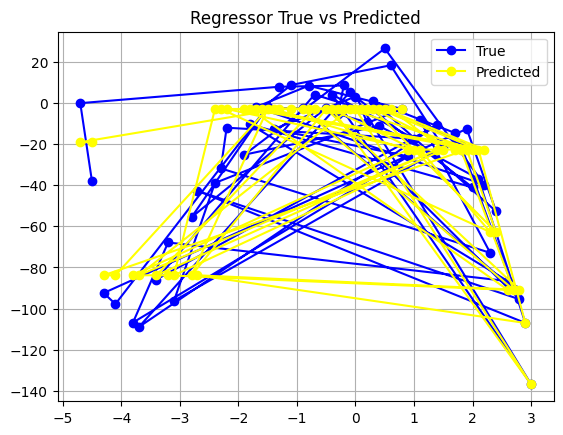

In [80]:
plot_regressor(tree_reg, regr_x_train, regr_y_train)

### (**Q6C**) Experiment with different maximum depth values and see how it affects the loss values and the predicted function

In [ ]:
for max_depth in max_depth_grid:
    model = build_tree_regressor(
        regr_x_train,
        regr_y_train,
        regr_x_test,
        regr_y_test,
        max_depth
    )
    plot_regressor(model, regr_x_train, regr_y_train)